# Find how long is Britain Coastline

course reference: https://rspatial.org/cases/2-coastline.html

Data Source: https://gadm.org/

#### Case study:

**How Long Is the Coast of Britain?**

Lewis Fry Richardson who showed that the length of a coastline changes with scale. Further, Benoît Mandelbrot used this data to calculate the fractal dimension D of Britain' coastline. For the west coast of Britain, Mandelbrot reports that D=1.25.

This tutorial shows how to measure the length of a coast line on different resolutions/scales (rulers of different length) and how to compute a fractal dimension.


In [ ]:
install.packages(c("terra", "geodata"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



terra 1.9.34

Cached as: ./gadm/gadm36_adm0_r3_pk.rds



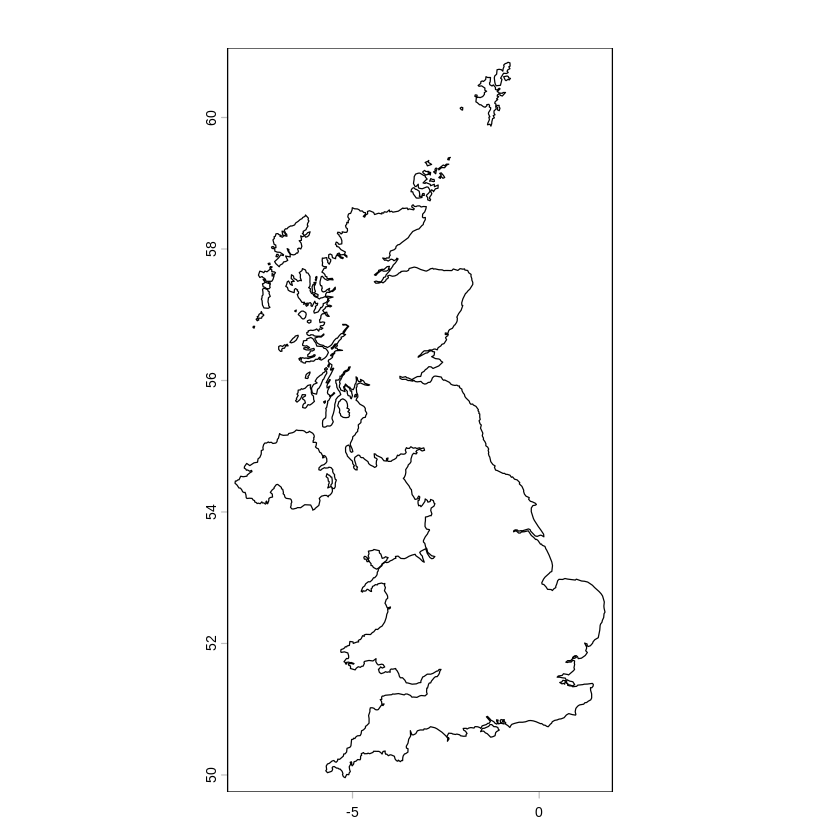

In [ ]:
# get a high spatial resolution (30 m) coastline for the United Kingdom from the GADM database.

library(terra)
library(geodata)

w <- world(path=".", resolution = 3)
uk <- w[w$GID_0=="GBR", ]
plot(uk)

This is a single “multi-polygon” (it has a single geometry) and a longitude/latitude coordinate reference system.

In [ ]:
# convert to data.frame
as.data.frame(uk)

GID_0,NAME_0
<chr>,<chr>
GBR,United Kingdom


Use the British National Grid coordinate reference system, "epsg:27700", which is based on the Transverse Mercator (tmerc) projection (in meters).

In [ ]:
prj <- "epsg:27700"
guk <- project(uk, prj)

# get main island by separating different polygons
duk <- disagg(guk)
head(duk)

GID_0,NAME_0
<chr>,<chr>
GBR,United Kingdom
GBR,United Kingdom
GBR,United Kingdom
GBR,United Kingdom
GBR,United Kingdom
GBR,United Kingdom


In [ ]:
# get largest feature
a <- expanse(duk)
i <- which.max(a)
a[i] / 1000000


[1] 219769.8

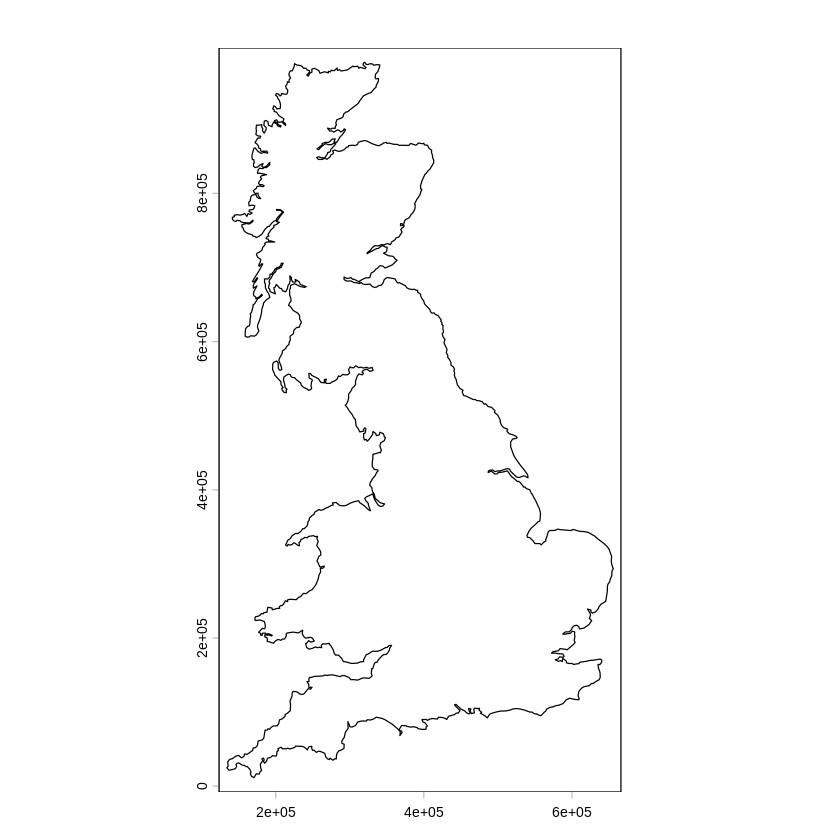

In [ ]:
b <- duk[i,]
par(mai=rep(0,4))
plot(b)

In [ ]:
# The function to go around the coast with a ruler (yardstick) of a certain length.
# get the coordinates of the polygon
measure_with_ruler <- function(pols, stick_length, lonlat=FALSE) {
    # some sanity checking
    stopifnot(inherits(pols, "SpatVector"))
    stopifnot(length(pols) == 1)
    # get the coordinates of the polygon
    g <- geom(pols)[, c('x', 'y')]
    nr <- nrow(g)
    # we start at the first point
    pts <- 1
    newpt <- 1
    while(TRUE) {
        # start here
        p <- newpt
        # order the points
        j <- p:(p+nr-1)
        j[j > nr] <- j[j > nr] - nr
        gg <- g[j,]
        # compute distances
        pd <- distance(gg[1,,drop=FALSE], gg, lonlat)
        pd <- as.vector(pd)
        # get the first point that is past the end of the ruler
        # this is precise enough for our high resolution coastline
        i <- which(pd > stick_length)[1]
        if (is.na(i)) {
            stop('Ruler is longer than the maximum distance found')
        }
        # get the record number for new point in the original order
        newpt <- i + p
        # stop if past the last point
        if (newpt >= nr) break
        pts <- c(pts, newpt)
    }
    # add the last (incomplete) stick.
    pts <- c(pts, 1)
    # return the locations
    g[pts, ]
}


In [ ]:
y <- list()
rulers <- c(25,50,100,150,200,250) # km
for (i in 1:length(rulers)) {
    y[[i]] <- measure_with_ruler(b, rulers[i]*1000)
}

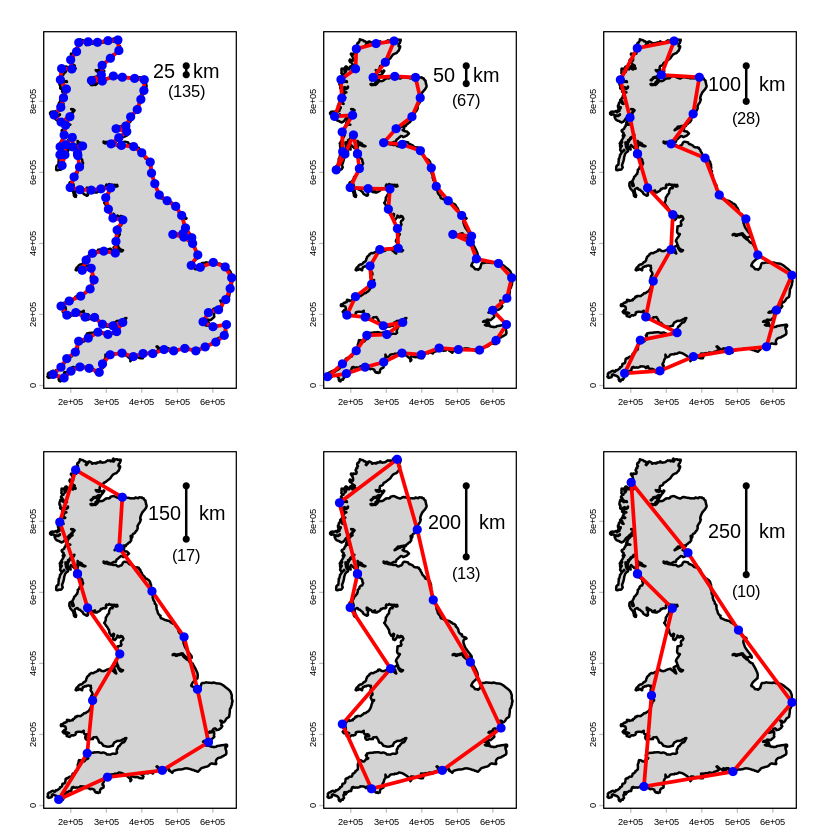

In [ ]:
# Object y is a list of matrices containing the locations where the ruler touched the coast.
# plot on top of the map of Britain.
par(mfrow=c(2,3), mai=rep(0,4))
for (i in 1:length(y)) {
    plot(b, col='lightgray', lwd=2)
    p <- y[[i]]
    lines(p, col='red', lwd=3)
    points(p, pch=20, col='blue', cex=2)
    bar <- rbind(cbind(525000, 900000), cbind(525000, 900000-rulers[i]*1000))
    lines(bar, lwd=2)
    points(bar, pch=20, cex=1.5)
    text(525000, mean(bar[,2]), paste(rulers[i], '  km'), cex=1.5)
    text(525000, bar[2,2]-50000, paste0('(', nrow(p), ')'), cex=1.25)
}

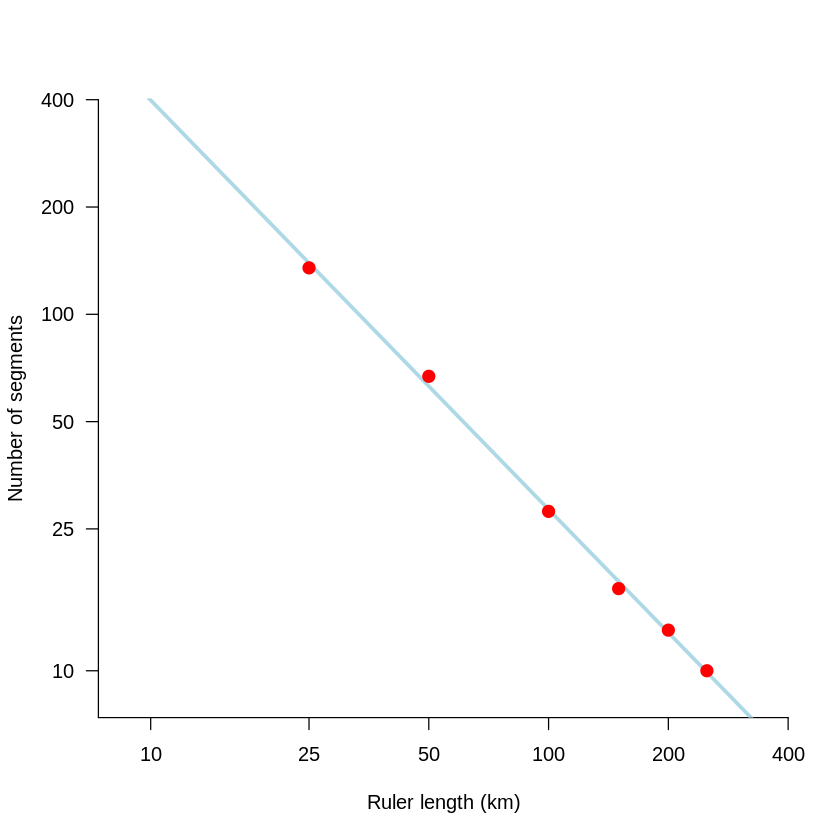

In [ ]:
#  the fractal (log-log) plot
# number of times a ruler was used
n <- sapply(y, nrow)
# set up empty plot
plot(log(rulers), log(n), type='n', xlim=c(2,6), ylim=c(2,6), axes=FALSE,
       xaxs="i",yaxs="i", xlab='Ruler length (km)', ylab='Number of segments')
# axes
tics <- c(1,10,25,50,100,200,400)
axis(1, at=log(tics), labels=tics)
axis(2, at=log(tics), labels=tics, las=2)
# linear regression line
m <- lm(log(n)~log(rulers))
abline(m, lwd=3, col='lightblue')
# add observations
points(log(rulers), log(n), pch=20, cex=2, col='red')

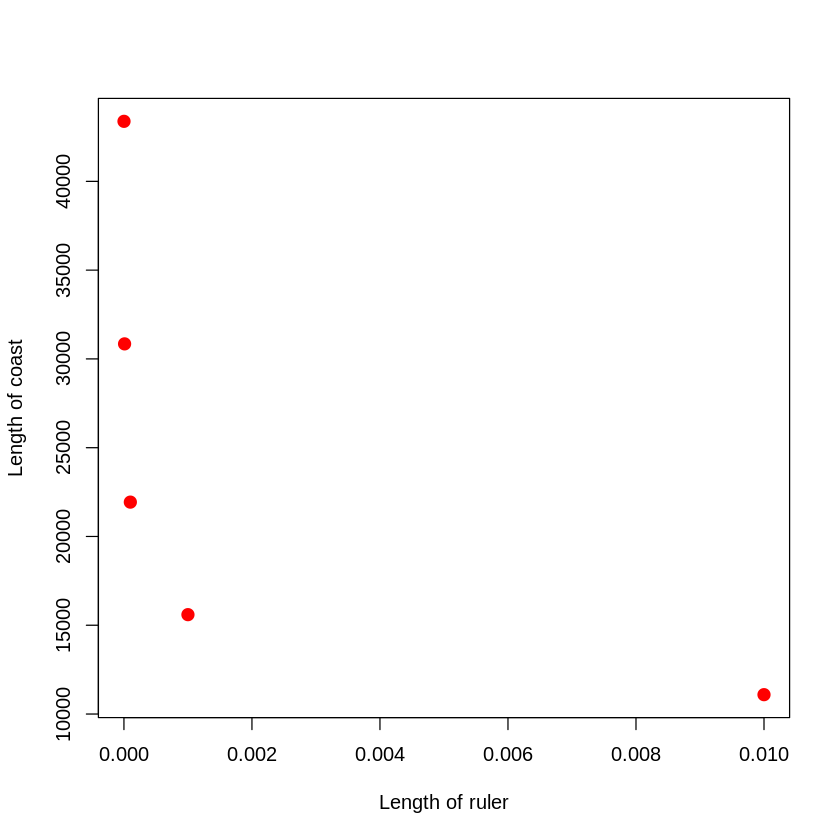

In [ ]:
# how about using very small rulers, from 1 mm to 10 m
small_rulers <- c(0.000001, 0.00001, 0.0001, 0.001, 0.01)  # km
nprd <- exp(predict(m, data.frame(rulers=small_rulers)))
coast <- nprd * small_rulers
plot(small_rulers, coast, xlab='Length of ruler', ylab='Length of coast', pch=20, cex=2, col='red')

the ruler get smaller, the coastline gets exponentially longer. As the ruler approaches zero, the length of the coastline approaches infinity.

The fractal dimension D of the coast of Britain is the (absolute value of the) slope of the regression line.

Final value is not to far away from Mandelbrot’s D = 1.25 for the west coast of Britain.



In [ ]:
print(m)

-1 * m$coefficients[2]


Call:
lm(formula = log(n) ~ log(rulers))

Coefficients:
(Intercept)  log(rulers)  
      8.632       -1.148  



log(rulers) 
   1.148083